# Experiment: Instance Validation and Exploratory Analysis

**Objetivo**

Usar o próprio notebook como workspace interativo principal para validar e explorar o release oficial `v1.1.0-observed`, reaproveitando o backend consolidado em `tools/instance_analysis_repl.py`.

**O que este notebook cobre**

- inventário do release oficial e contexto estrutural
- validação estrutural e reconciliação dos audits
- comportamento da camada observacional
- sanidade operacional por regime
- drilldown visual de uma instância concreta

**Modo de uso**

Este notebook é a interface interativa principal. O módulo `tools/instance_analysis_repl.py` funciona como backend compartilhado da análise, para evitar duas implementações diferentes do mesmo pipeline analítico.


In [1]:
# Setup: notebook runtime, paths and shared backend
from __future__ import annotations

import importlib
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "instances").exists() and (candidate / "catalog").exists() and (candidate / "tools").exists():
            return candidate
    raise RuntimeError("Could not locate repository root from current working directory.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
ARTIFACT_DIR = REPO_ROOT / "output" / "jupyter-notebook" / "instance_validation_analysis_artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

TOOLS_DIR = REPO_ROOT / "tools"
if str(TOOLS_DIR) not in sys.path:
    sys.path.insert(0, str(TOOLS_DIR))

import instance_analysis_repl as repl

repl = importlib.reload(repl)

SEED = repl.SEED
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

STAGE_ORDER = repl.STAGE_ORDER
REGIME_ORDER = repl.REGIME_ORDER
SCALE_ORDER = repl.SCALE_ORDER


## Plan

1. Carregar o backend analítico compartilhado e expor os objetos principais no notebook.
2. Validar integridade estrutural, reconciliar audits e inspecionar métricas agregadas do release.
3. Verificar se a camada observacional reduz sobre-determinismo sem quebrar a semântica operacional.
4. Fazer drilldown visual em uma instância para checagem manual do baseline FIFO.


In [2]:
# Bootstrap the notebook workspace from the shared REPL backend
CTX = repl.CTX
SUMMARY = repl.SUMMARY

params = repl.PARAMS.copy()
catalog = repl.CATALOG.copy()
family_summary = repl.FAMILY_SUMMARY.copy()
observed_noise_manifest = repl.OBSERVED_NOISE_MANIFEST
manifest = repl.MANIFEST

jobs = repl.JOBS.copy()
jobs_enriched = repl.JOBS_ENRICHED.copy()
operations = repl.OPERATIONS.copy()
eligible = repl.ELIGIBLE.copy()
machines = repl.MACHINES.copy()
precedences = repl.PRECEDENCES.copy()
downtimes = repl.DOWNTIMES.copy()
events = repl.EVENTS.copy()
schedule = repl.SCHEDULE.copy()
job_metrics = repl.JOB_METRICS.copy()
due_audit = repl.DUE_AUDIT.copy()
proc_audit = repl.PROC_AUDIT.copy()
proc_audit_enriched = repl.PROC_AUDIT_ENRICHED.copy()
congestion = repl.CONGESTION.copy()

structural_report = repl.STRUCTURAL_REPORT.copy()
event_report = repl.EVENT_REPORT.copy()
audit_reconciliation = repl.AUDIT_RECONCILIATION.copy()
regime_checks = repl.REGIME_CHECKS.copy()
utilization = repl.UTILIZATION.copy()
diagnostics = repl.DIAGNOSTICS.copy()
unload = repl.UNLOAD.copy()

validation_observed = pd.read_csv(REPO_ROOT / "catalog" / "validation_report_observed.csv")
validation_nominal_style = pd.read_csv(REPO_ROOT / "catalog" / "validation_report.csv")
g2milp_contract = json.loads((REPO_ROOT / "catalog" / "g2milp_generation_contract.json").read_text(encoding="utf-8"))

inventory_summary = pd.DataFrame([SUMMARY])
display(inventory_summary)
display(
    Markdown(
        """
**Quick start interativo**

- `SUMMARY`
- `params.head()`
- `structural_report.head()`
- `repl.plot_inventory_overview()`
- `repl.plot_validation_overview()`
- `repl.plot_observational_layer()`
- `repl.plot_operational_sanity()`
- `repl.plot_instance_drilldown("GO_XS_DISRUPTED_01")`
"""
    )
)


,dataset_version,instance_count,job_count,operation_count,eligible_rows,machine_rows,structural_pass_rate,due_audit_match_share,proc_audit_match_share,r2_due_slack_vs_priority,r2_unload_proc_vs_load_machine_moisture,all_regime_order_checks_pass,g2milp_role
0,1.1.0-observed,36,1848,7392,21167,306,1.0,1.0,1.0,0.4848,0.4995,True,base_dataset_for_g2milp_instance_generation



**Quick start interativo**

- `SUMMARY`
- `params.head()`
- `structural_report.head()`
- `repl.plot_inventory_overview()`
- `repl.plot_validation_overview()`
- `repl.plot_observational_layer()`
- `repl.plot_operational_sanity()`
- `repl.plot_instance_drilldown("GO_XS_DISRUPTED_01")`


In [3]:
# Release metadata and provenance checks
noise_manifest_summary = pd.DataFrame(
    [
        {
            "dataset_version": manifest["dataset_version"],
            "official_dataset_role": manifest["official_dataset_role"],
            "noise_model_id": observed_noise_manifest.get("model_id"),
            "noise_global_seed": observed_noise_manifest.get("global_seed"),
            "parent_dataset_version": observed_noise_manifest.get("parent_dataset_version"),
            "generator_model": observed_noise_manifest.get("generator_model", "ChatGPT 5.4 PRO"),
        }
    ]
)

display(params.head())
display(noise_manifest_summary)
display(pd.DataFrame([g2milp_contract]).iloc[:, :8])


,dataset_name,dataset_version,instance_id,scale_code,regime_code,replicate,random_seed,time_unit,load_unit,currency,planning_horizon_min,shift_open_min,shift_close_min,antt_statutory_wait_limit_min,antt_wait_cost_rs_per_ton_hour,notes,parent_dataset_version,observational_noise_model_id,observational_noise_seed
0,Agro Yard D-FJSP GO Benchmark,1.1.0-observed,GO_L_BALANCED_01,L,balanced,1,41111,minute,ton,BRL,1080,0,720,300,2.41,Structured observational-noise derivative of t...,1.0.0,pequiflux_observed_noise_v1_1,817207134
1,Agro Yard D-FJSP GO Benchmark,1.1.0-observed,GO_L_BALANCED_02,L,balanced,2,42111,minute,ton,BRL,1080,0,720,300,2.41,Structured observational-noise derivative of t...,1.0.0,pequiflux_observed_noise_v1_1,3851404905
2,Agro Yard D-FJSP GO Benchmark,1.1.0-observed,GO_L_BALANCED_03,L,balanced,3,43111,minute,ton,BRL,1080,0,720,300,2.41,Structured observational-noise derivative of t...,1.0.0,pequiflux_observed_noise_v1_1,482397280
3,Agro Yard D-FJSP GO Benchmark,1.1.0-observed,GO_L_DISRUPTED_01,L,disrupted,1,41333,minute,ton,BRL,1080,0,720,300,2.41,Structured observational-noise derivative of t...,1.0.0,pequiflux_observed_noise_v1_1,569216366
4,Agro Yard D-FJSP GO Benchmark,1.1.0-observed,GO_L_DISRUPTED_02,L,disrupted,2,42333,minute,ton,BRL,1080,0,720,300,2.41,Structured observational-noise derivative of t...,1.0.0,pequiflux_observed_noise_v1_1,1131596359


,dataset_version,official_dataset_role,noise_model_id,noise_global_seed,parent_dataset_version,generator_model
0,1.1.0-observed,base_dataset_for_g2milp_instance_generation,pequiflux_observed_noise_v1_1,20260327,None,ChatGPT 5.4 PRO


,official_dataset_role,parent_dataset_version,generator_model_family,dataset_is_frozen_parent,required_child_lineage_fields,minimum_child_validation_requirements,documentation_ref
0,base_dataset_for_g2milp_instance_generation,1.1.0-observed,G2MILP,True,"[parent_dataset_name, parent_dataset_version, ...",[four_operations_per_job_or_declared_structura...,docs/g2milp_generation_contract.md


## Inventory and structural context

Esta seção responde:

- quantas instâncias, jobs, operações, máquinas e linhas elegíveis existem
- como as famílias `XS/S/M/L` e os regimes `balanced/peak/disrupted` estão distribuídos
- se os artefatos de auditoria e catálogo estão completos


,instance_id,relative_path,scale_code,regime_code,replicate,random_seed,n_jobs,n_machines,n_scales,n_labs,n_hoppers,n_breakdowns,share_urgent,share_appointment,avg_load_tons,avg_unload_proc_time_min,fifo_makespan_min,fifo_mean_flow_min,fifo_p95_flow_min,fifo_overwait_share,recommended_solver_track
0,GO_L_BALANCED_01,instances/GO_L_BALANCED_01,L,balanced,1,41111,72,13,4,3,6,0,0.0278,0.7500,38.78,24.08,670,52.99,68,0.0,metaheuristic
1,GO_L_BALANCED_02,instances/GO_L_BALANCED_02,L,balanced,2,42111,72,13,4,3,6,0,0.0278,0.7500,37.89,24.33,681,58.69,87,0.0,metaheuristic
2,GO_L_BALANCED_03,instances/GO_L_BALANCED_03,L,balanced,3,43111,72,13,4,3,6,0,0.0278,0.7500,38.81,25.91,655,50.44,57,0.0,metaheuristic
3,GO_L_DISRUPTED_01,instances/GO_L_DISRUPTED_01,L,disrupted,1,41333,96,13,4,3,6,3,0.1979,0.5938,38.57,28.56,617,101.03,148,0.0,metaheuristic
4,GO_L_DISRUPTED_02,instances/GO_L_DISRUPTED_02,L,disrupted,2,42333,96,13,4,3,6,2,0.1771,0.6354,37.85,24.08,591,93.40,150,0.0,metaheuristic
5,GO_L_DISRUPTED_03,instances/GO_L_DISRUPTED_03,L,disrupted,3,43333,96,13,4,3,6,2,0.1875,0.5938,37.96,25.93,601,93.71,141,0.0,metaheuristic
6,GO_L_PEAK_01,instances/GO_L_PEAK_01,L,peak,1,41222,96,13,4,3,6,0,0.0833,0.6562,38.25,25.81,643,94.60,163,0.0,metaheuristic
7,GO_L_PEAK_02,instances/GO_L_PEAK_02,L,peak,2,42222,96,13,4,3,6,0,0.1354,0.7083,38.06,25.49,662,73.54,112,0.0,metaheuristic
8,GO_L_PEAK_03,instances/GO_L_PEAK_03,L,peak,3,43222,96,13,4,3,6,0,0.0729,0.6354,38.07,23.50,671,78.89,127,0.0,metaheuristic
9,GO_M_BALANCED_01,instances/GO_M_BALANCED_01,M,balanced,1,31111,48,9,3,2,4,0,0.0417,0.7292,37.79,27.74,673,55.35,68,0.0,hybrid


,scale_code,regime_code,instance_count,avg_n_jobs,avg_fifo_makespan_min,avg_fifo_mean_flow_min,avg_fifo_p95_flow_min,avg_fifo_overwait_share
0,L,balanced,3,72.0,668.67,54.04,70.67,0.00
1,L,disrupted,3,96.0,603.00,96.05,146.33,0.00
2,L,peak,3,96.0,658.67,82.34,134.00,0.00
3,M,balanced,3,48.0,677.00,54.52,66.33,0.00
4,M,disrupted,3,64.0,615.00,97.68,145.00,0.00
5,M,peak,3,64.0,646.33,71.02,106.33,0.00
6,S,balanced,3,30.0,690.00,59.10,78.33,0.00
7,S,disrupted,3,40.0,598.33,89.06,142.00,0.00
8,S,peak,3,40.0,632.33,74.23,107.67,0.00
9,XS,balanced,3,18.0,645.00,73.57,100.00,0.00


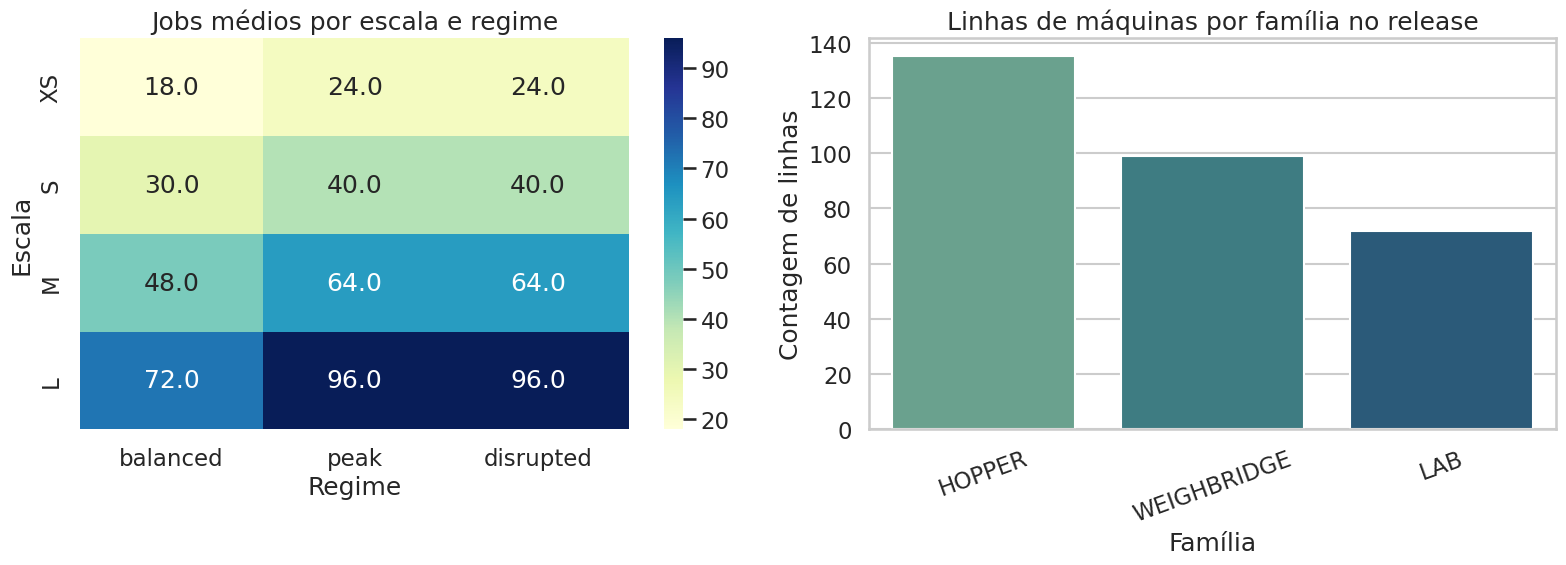

In [4]:
display(catalog.sort_values(["scale_code", "regime_code", "replicate"]).head(12))
display(family_summary.sort_values(["scale_code", "regime_code"]))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

jobs_heatmap = family_summary.pivot(index="scale_code", columns="regime_code", values="avg_n_jobs").reindex(index=SCALE_ORDER, columns=REGIME_ORDER)
sns.heatmap(jobs_heatmap, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("Jobs médios por escala e regime")
axes[0].set_xlabel("Regime")
axes[0].set_ylabel("Escala")

machine_family = (
    machines.groupby(["machine_family"], as_index=False)["machine_id"]
    .count()
    .rename(columns={"machine_id": "machine_rows"})
    .sort_values("machine_rows", ascending=False)
)
sns.barplot(data=machine_family, x="machine_family", y="machine_rows", hue="machine_family", dodge=False, legend=False, ax=axes[1], palette="crest")
axes[1].set_title("Linhas de máquinas por família no release")
axes[1].set_xlabel("Família")
axes[1].set_ylabel("Contagem de linhas")
axes[1].tick_params(axis="x", rotation=20)

fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "inventory_overview.png", dpi=160, bbox_inches="tight")
plt.show()


## Structural validation and auditability

Aqui reaplicamos o verificador estrutural do release e complementamos com:

- consistência de eventos
- margem do prazo sobre o lower bound nominal
- reconciliação auditável entre arquivos centrais e CSVs de audit


,instance_id,issue_count,issues,status,scale_code,regime_code
0,GO_L_BALANCED_01,0,,PASS,L,balanced
1,GO_L_BALANCED_02,0,,PASS,L,balanced
2,GO_L_BALANCED_03,0,,PASS,L,balanced
3,GO_L_DISRUPTED_01,0,,PASS,L,disrupted
4,GO_L_DISRUPTED_02,0,,PASS,L,disrupted
5,GO_L_DISRUPTED_03,0,,PASS,L,disrupted
6,GO_L_PEAK_01,0,,PASS,L,peak
7,GO_L_PEAK_02,0,,PASS,L,peak
8,GO_L_PEAK_03,0,,PASS,L,peak
9,GO_M_BALANCED_01,0,,PASS,M,balanced


,instance_id,job_visible_mismatch,job_arrival_mismatch,machine_down_missing,machine_up_missing,scale_code,regime_code
0,GO_L_BALANCED_01,0,0,0,0,L,balanced
1,GO_L_BALANCED_02,0,0,0,0,L,balanced
2,GO_L_BALANCED_03,0,0,0,0,L,balanced
3,GO_L_DISRUPTED_01,0,0,0,0,L,disrupted
4,GO_L_DISRUPTED_02,0,0,0,0,L,disrupted
5,GO_L_DISRUPTED_03,0,0,0,0,L,disrupted
6,GO_L_PEAK_01,0,0,0,0,L,peak
7,GO_L_PEAK_02,0,0,0,0,L,peak
8,GO_L_PEAK_03,0,0,0,0,L,peak
9,GO_M_BALANCED_01,0,0,0,0,M,balanced


,instance_id,due_match_share,proc_match_share,scale_code,regime_code
0,GO_L_BALANCED_01,1.0,1.0,L,balanced
1,GO_L_BALANCED_02,1.0,1.0,L,balanced
2,GO_L_BALANCED_03,1.0,1.0,L,balanced
3,GO_L_DISRUPTED_01,1.0,1.0,L,disrupted
4,GO_L_DISRUPTED_02,1.0,1.0,L,disrupted
5,GO_L_DISRUPTED_03,1.0,1.0,L,disrupted
6,GO_L_PEAK_01,1.0,1.0,L,peak
7,GO_L_PEAK_02,1.0,1.0,L,peak
8,GO_L_PEAK_03,1.0,1.0,L,peak
9,GO_M_BALANCED_01,1.0,1.0,M,balanced


,index,scale_code,regime_code,mean,min,median,max
0,0,L,balanced,249.80,154,251.0,301
1,1,L,disrupted,258.99,141,264.0,353
2,2,L,peak,257.97,172,264.0,314
3,3,M,balanced,239.47,146,243.0,295
4,4,M,disrupted,262.74,158,269.0,331
5,5,M,peak,246.40,162,249.0,327
6,6,S,balanced,248.60,179,254.5,288
7,7,S,disrupted,255.80,189,261.0,331
8,8,S,peak,246.94,173,254.0,300
9,9,XS,balanced,233.09,169,237.5,268


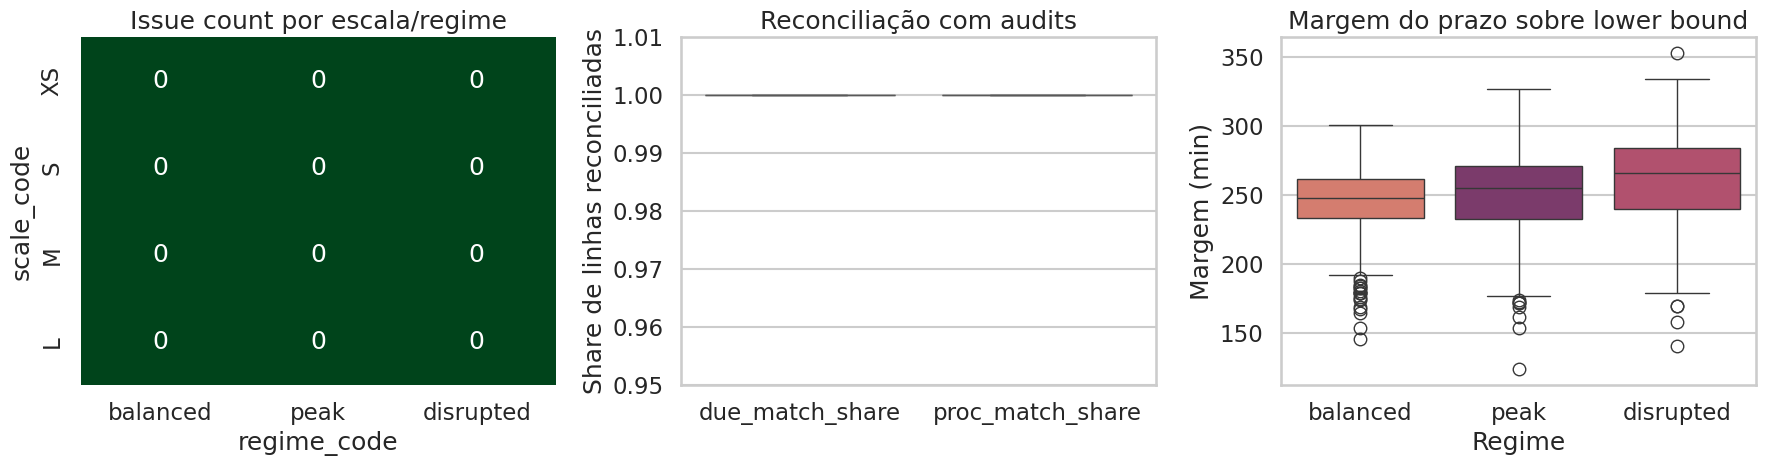

In [5]:
# The shared REPL backend already ships these reports with scale/regime context.

display(structural_report.sort_values(["scale_code", "regime_code", "instance_id"]))
display(event_report.sort_values(["scale_code", "regime_code", "instance_id"]))
display(audit_reconciliation.sort_values(["scale_code", "regime_code", "instance_id"]))

due_margin_summary = (
    jobs_enriched.groupby(["scale_code", "regime_code"], as_index=False)["due_margin_over_lb_min"]
    .agg(["mean", "min", "median", "max"])
    .round(2)
    .reset_index()
)
display(due_margin_summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

issue_heatmap = structural_report.pivot_table(
    index="scale_code",
    columns="regime_code",
    values="issue_count",
    aggfunc="sum",
    fill_value=0,
).reindex(index=SCALE_ORDER, columns=REGIME_ORDER)
sns.heatmap(issue_heatmap, annot=True, fmt=".0f", cmap="Greens_r", ax=axes[0], cbar=False)
axes[0].set_title("Issue count por escala/regime")

audit_long = audit_reconciliation.melt(
    id_vars=["instance_id", "scale_code", "regime_code"],
    value_vars=["due_match_share", "proc_match_share"],
    var_name="check",
    value_name="match_share",
)
sns.boxplot(data=audit_long, x="check", y="match_share", hue="check", dodge=False, legend=False, ax=axes[1], palette="Set2")
axes[1].set_title("Reconciliação com audits")
axes[1].set_xlabel("")
axes[1].set_ylabel("Share de linhas reconciliadas")
axes[1].set_ylim(0.95, 1.01)

sns.boxplot(data=jobs_enriched, x="regime_code", y="due_margin_over_lb_min", order=REGIME_ORDER, hue="regime_code", dodge=False, legend=False, ax=axes[2], palette="flare")
axes[2].set_title("Margem do prazo sobre lower bound")
axes[2].set_xlabel("Regime")
axes[2].set_ylabel("Margem (min)")

fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "structural_validation_and_auditability.png", dpi=160, bbox_inches="tight")
plt.show()

structural_report.to_csv(ARTIFACT_DIR / "structural_report.csv", index=False)
event_report.to_csv(ARTIFACT_DIR / "event_report.csv", index=False)
audit_reconciliation.to_csv(ARTIFACT_DIR / "audit_reconciliation.csv", index=False)
due_margin_summary.to_csv(ARTIFACT_DIR / "due_margin_summary.csv", index=False)


## Observational layer behavior

Esta seção testa se a camada observacional cumpriu seu papel:

- a prioridade continua importante, mas não perfeitamente determinística
- tempos de `UNLOAD` continuam interpretáveis por carga, máquina, umidade e congestionamento
- o ruído aparece de forma estruturada, e não como barulho arbitrário


,r2_due_slack_vs_priority,r2_unload_proc_vs_load_machine_moisture
0,0.4848,0.4995


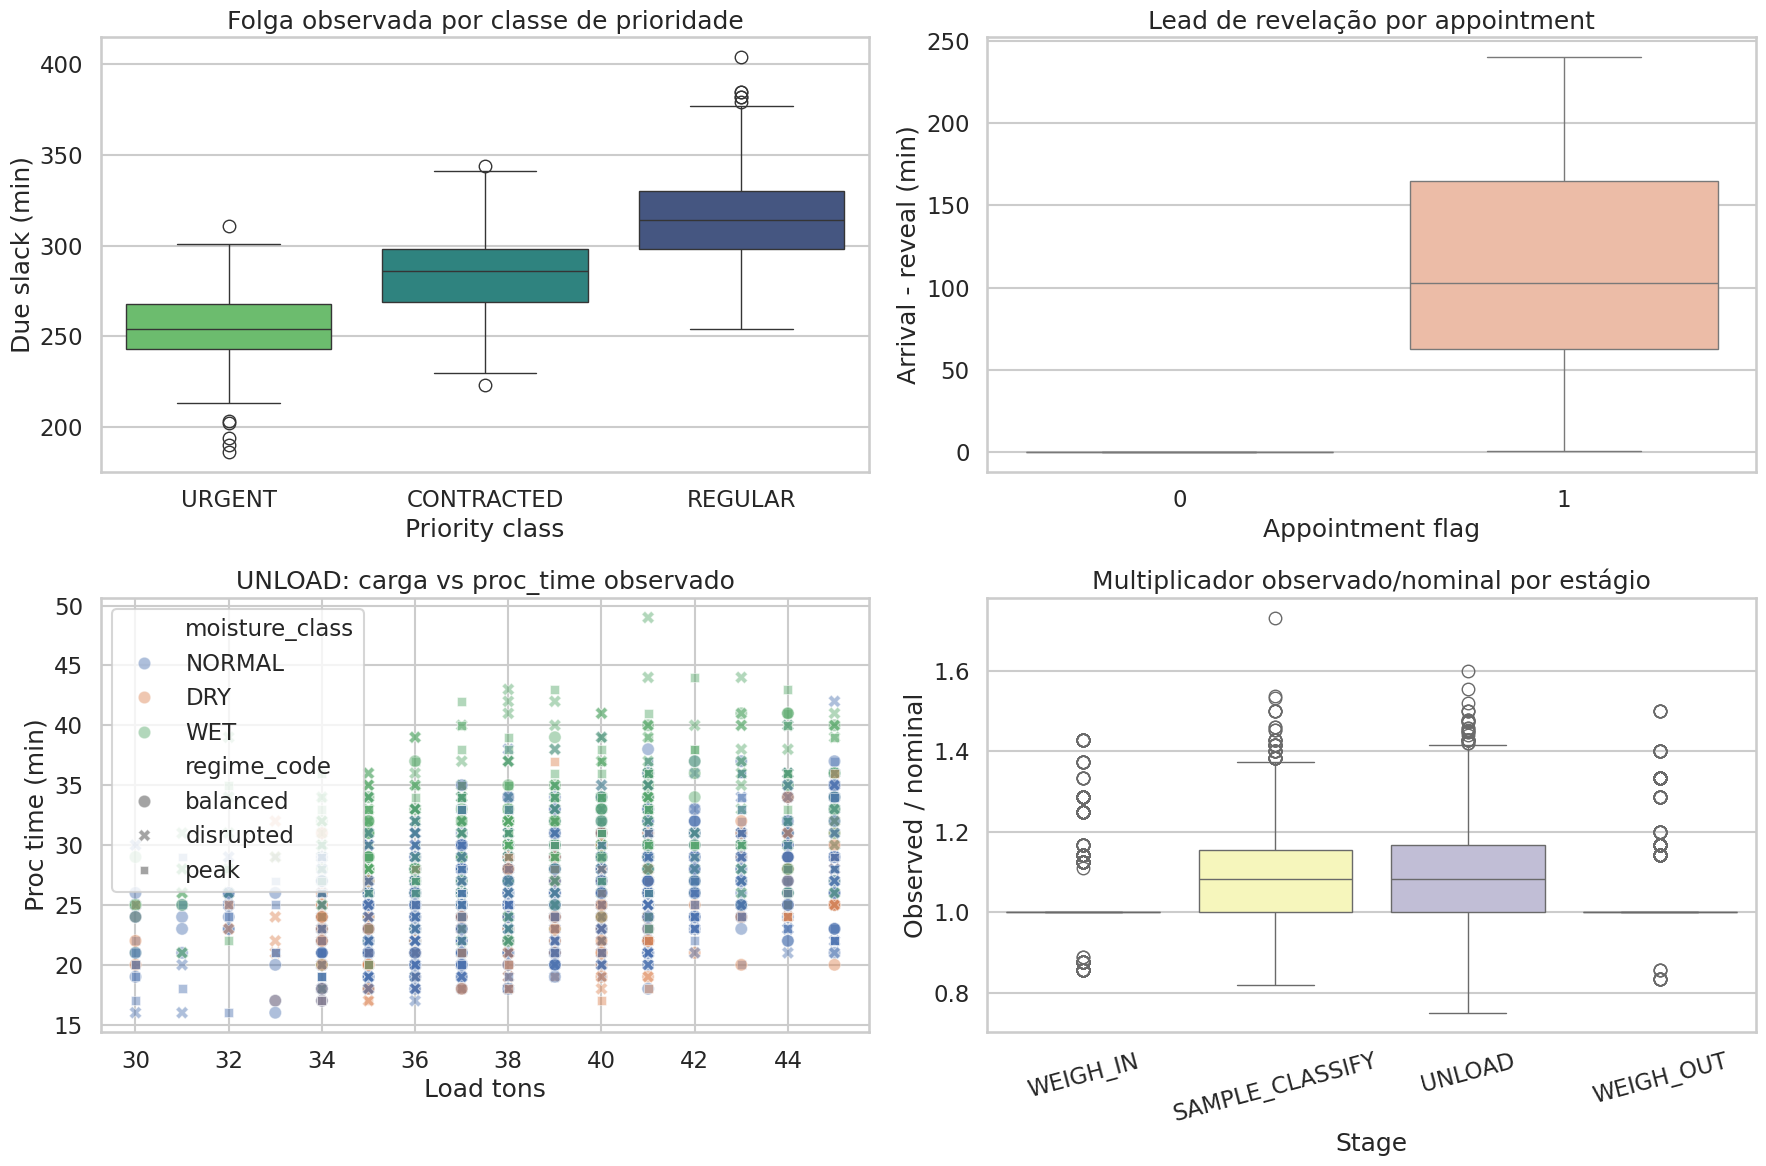

In [6]:
diagnostics_df = pd.DataFrame([diagnostics])
display(diagnostics_df)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.boxplot(data=jobs_enriched, x="priority_class", y="due_slack_min", order=["URGENT", "CONTRACTED", "REGULAR"], hue="priority_class", dodge=False, legend=False, ax=axes[0, 0], palette="viridis")
axes[0, 0].set_title("Folga observada por classe de prioridade")
axes[0, 0].set_xlabel("Priority class")
axes[0, 0].set_ylabel("Due slack (min)")

sns.boxplot(data=jobs_enriched, x="appointment_flag", y="reveal_lead_min", hue="appointment_flag", dodge=False, legend=False, ax=axes[0, 1], palette="coolwarm")
axes[0, 1].set_title("Lead de revelação por appointment")
axes[0, 1].set_xlabel("Appointment flag")
axes[0, 1].set_ylabel("Arrival - reveal (min)")

sns.scatterplot(
    data=unload.sample(min(len(unload), 2500), random_state=SEED),
    x="load_tons",
    y="proc_time_min",
    hue="moisture_class",
    style="regime_code",
    alpha=0.45,
    ax=axes[1, 0],
)
axes[1, 0].set_title("UNLOAD: carga vs proc_time observado")
axes[1, 0].set_xlabel("Load tons")
axes[1, 0].set_ylabel("Proc time (min)")

sns.boxplot(data=proc_audit_enriched, x="stage_name", y="proc_multiplier", order=STAGE_ORDER, hue="stage_name", dodge=False, legend=False, ax=axes[1, 1], palette="Set3")
axes[1, 1].set_title("Multiplicador observado/nominal por estágio")
axes[1, 1].set_xlabel("Stage")
axes[1, 1].set_ylabel("Observed / nominal")
axes[1, 1].tick_params(axis="x", rotation=15)

fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "observational_layer_behavior.png", dpi=160, bbox_inches="tight")
plt.show()


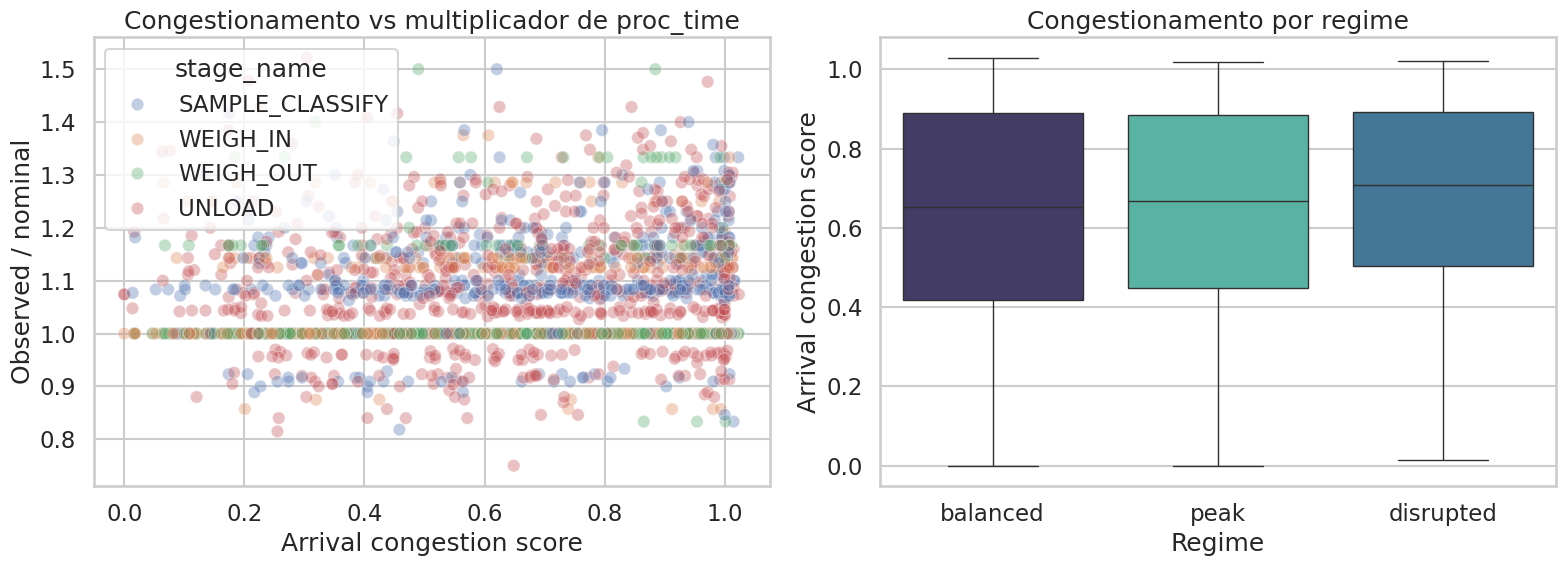

In [7]:
congestion_vs_proc = proc_audit_enriched.copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=congestion_vs_proc.sample(min(len(congestion_vs_proc), 3000), random_state=SEED),
    x="arrival_congestion_score",
    y="proc_multiplier",
    hue="stage_name",
    alpha=0.35,
    ax=axes[0],
)
axes[0].set_title("Congestionamento vs multiplicador de proc_time")
axes[0].set_xlabel("Arrival congestion score")
axes[0].set_ylabel("Observed / nominal")

sns.boxplot(data=jobs_enriched, x="regime_code", y="arrival_congestion_score", order=REGIME_ORDER, hue="regime_code", dodge=False, legend=False, ax=axes[1], palette="mako")
axes[1].set_title("Congestionamento por regime")
axes[1].set_xlabel("Regime")
axes[1].set_ylabel("Arrival congestion score")

fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "congestion_diagnostics.png", dpi=160, bbox_inches="tight")
plt.show()


## Operational performance and regime sanity

A validação não depende só de integridade estrutural. Também interessa saber se:

- `balanced < peak < disrupted` permanece verdadeiro
- os tempos de fluxo e fila continuam coerentes com a escala do problema
- a utilização de recurso faz sentido por família de máquina


,scale_code,mean_flow_order_ok,p95_flow_order_ok
0,L,True,True
1,M,True,True
2,S,True,True
3,XS,True,True


,scale_code,regime_code,instance_count,avg_n_jobs,avg_fifo_makespan_min,avg_fifo_mean_flow_min,avg_fifo_p95_flow_min,avg_fifo_overwait_share
0,L,balanced,3,72.0,668.67,54.04,70.67,0.00
1,L,disrupted,3,96.0,603.00,96.05,146.33,0.00
2,L,peak,3,96.0,658.67,82.34,134.00,0.00
3,M,balanced,3,48.0,677.00,54.52,66.33,0.00
4,M,disrupted,3,64.0,615.00,97.68,145.00,0.00
5,M,peak,3,64.0,646.33,71.02,106.33,0.00
6,S,balanced,3,30.0,690.00,59.10,78.33,0.00
7,S,disrupted,3,40.0,598.33,89.06,142.00,0.00
8,S,peak,3,40.0,632.33,74.23,107.67,0.00
9,XS,balanced,3,18.0,645.00,73.57,100.00,0.00


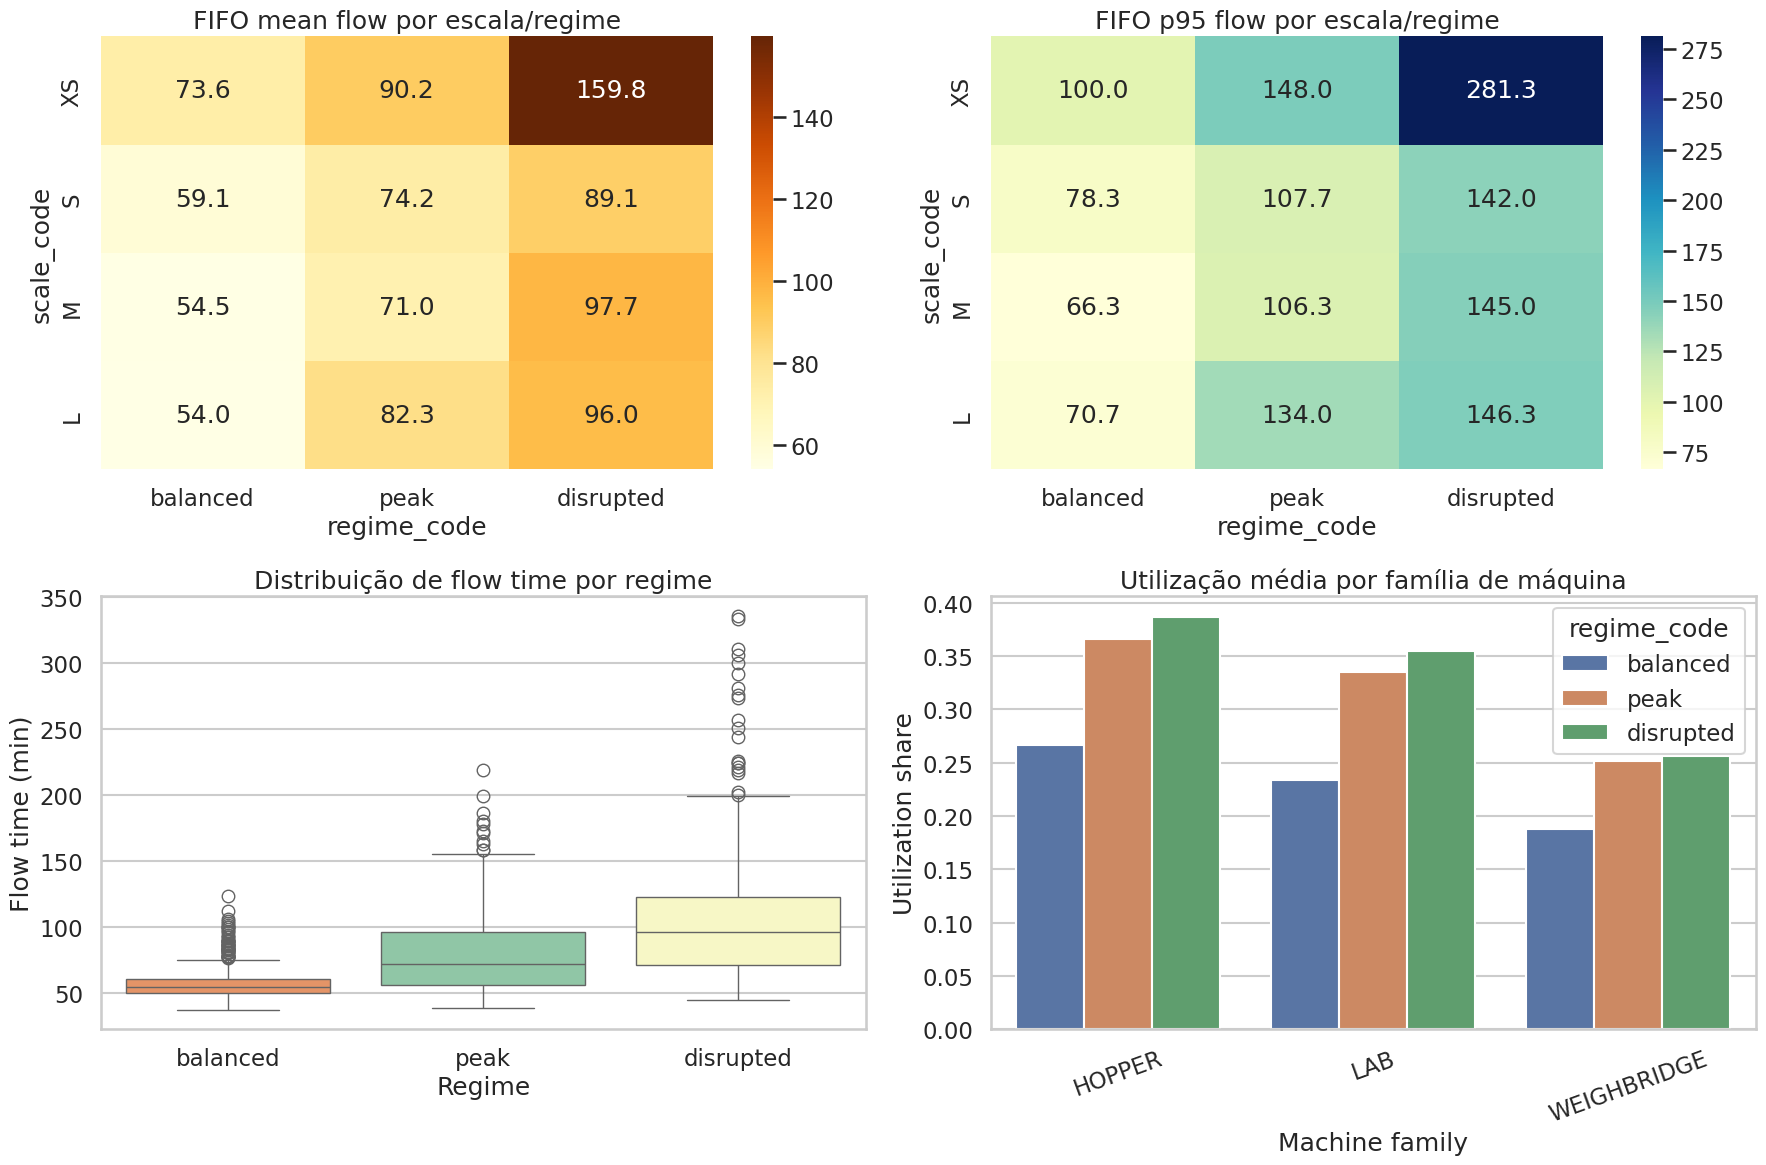

In [8]:
display(regime_checks)
display(family_summary.sort_values(["scale_code", "regime_code"]))

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

mean_heatmap = family_summary.pivot(index="scale_code", columns="regime_code", values="avg_fifo_mean_flow_min").reindex(index=SCALE_ORDER, columns=REGIME_ORDER)
sns.heatmap(mean_heatmap, annot=True, fmt=".1f", cmap="YlOrBr", ax=axes[0, 0])
axes[0, 0].set_title("FIFO mean flow por escala/regime")

p95_heatmap = family_summary.pivot(index="scale_code", columns="regime_code", values="avg_fifo_p95_flow_min").reindex(index=SCALE_ORDER, columns=REGIME_ORDER)
sns.heatmap(p95_heatmap, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[0, 1])
axes[0, 1].set_title("FIFO p95 flow por escala/regime")

sns.boxplot(data=job_metrics, x="regime_code", y="flow_time_min", order=REGIME_ORDER, hue="regime_code", dodge=False, legend=False, ax=axes[1, 0], palette="Spectral")
axes[1, 0].set_title("Distribuição de flow time por regime")
axes[1, 0].set_xlabel("Regime")
axes[1, 0].set_ylabel("Flow time (min)")

util_plot = (
    utilization.groupby(["machine_family", "regime_code"], as_index=False)["utilization_share"]
    .mean()
)
sns.barplot(data=util_plot, x="machine_family", y="utilization_share", hue="regime_code", hue_order=REGIME_ORDER, ax=axes[1, 1], palette="deep")
axes[1, 1].set_title("Utilização média por família de máquina")
axes[1, 1].set_xlabel("Machine family")
axes[1, 1].set_ylabel("Utilization share")
axes[1, 1].tick_params(axis="x", rotation=20)

fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "operational_performance_and_regime_sanity.png", dpi=160, bbox_inches="tight")
plt.show()


## Instance drilldown

Um drilldown ajuda a validar visualmente se o baseline FIFO de uma instância concreta:

- respeita o fluxo por máquina
- evita overlap
- incorpora downtimes
- produz métricas coerentes com o regime escolhido


,dataset_name,dataset_version,instance_id,scale_code,regime_code,replicate,random_seed,time_unit,load_unit,currency,planning_horizon_min,shift_open_min,shift_close_min,antt_statutory_wait_limit_min,antt_wait_cost_rs_per_ton_hour,notes,parent_dataset_version,observational_noise_model_id,observational_noise_seed
30,Agro Yard D-FJSP GO Benchmark,1.1.0-observed,GO_XS_DISRUPTED_01,XS,disrupted,1,11333,minute,ton,BRL,1080,0,720,300,2.41,Structured observational-noise derivative of t...,1.0.0,pequiflux_observed_noise_v1_1,2360242032


,instance_id,relative_path,scale_code,regime_code,replicate,random_seed,n_jobs,n_machines,n_scales,n_labs,n_hoppers,n_breakdowns,share_urgent,share_appointment,avg_load_tons,avg_unload_proc_time_min,fifo_makespan_min,fifo_mean_flow_min,fifo_p95_flow_min,fifo_overwait_share,recommended_solver_track
30,GO_XS_DISRUPTED_01,instances/GO_XS_DISRUPTED_01,XS,disrupted,1,11333,24,5,2,1,2,2,0.2083,0.4583,38.33,34.12,717,140.71,288,0.0417,exact


,job_id,commodity,load_tons,arrival_time_min,reveal_time_min,priority_class,priority_weight,appointment_flag,moisture_class,statutory_wait_limit_min,completion_due_min,overwait_cost_rs_per_min,shift_bucket,arrival_congestion_score,instance_id,scale_code,regime_code,replicate,dataset_version,nominal_lb_min,due_slack_min,due_margin_over_lb_min,reveal_lead_min
1704,J0001,SOY,35,37,37,CONTRACTED,1.25,0,NORMAL,300,343,1.4058,EARLY,0.322444,GO_XS_DISRUPTED_01,XS,disrupted,1,1.1.0-observed,57,306,249,0
1705,J0002,SORGHUM,31,68,68,REGULAR,1.00,0,WET,300,413,1.2452,EARLY,0.820252,GO_XS_DISRUPTED_01,XS,disrupted,1,1.1.0-observed,61,345,284,0
1706,J0003,CORN,45,70,7,CONTRACTED,1.25,1,NORMAL,300,340,1.8075,EARLY,0.842879,GO_XS_DISRUPTED_01,XS,disrupted,1,1.1.0-observed,60,270,210,63
1707,J0004,CORN,35,71,64,URGENT,1.75,1,NORMAL,300,318,1.4058,EARLY,0.848536,GO_XS_DISRUPTED_01,XS,disrupted,1,1.1.0-observed,53,247,194,7
1708,J0005,CORN,44,73,73,REGULAR,1.00,0,NORMAL,300,409,1.7673,EARLY,0.848536,GO_XS_DISRUPTED_01,XS,disrupted,1,1.1.0-observed,62,336,274,0


,completion_min,flow_time_min,queue_time_min,overwait_min,replicate
count,24.00,24.00,24.00,24.00,24.0
mean,369.42,140.71,78.92,1.42,1.0
std,190.25,71.99,71.23,6.94,0.0
min,94.00,57.00,0.00,0.00,1.0
25%,211.00,93.50,31.75,0.00,1.0
50%,354.50,126.50,66.50,0.00,1.0
75%,497.50,162.50,106.00,0.00,1.0
max,717.00,334.00,268.00,34.00,1.0


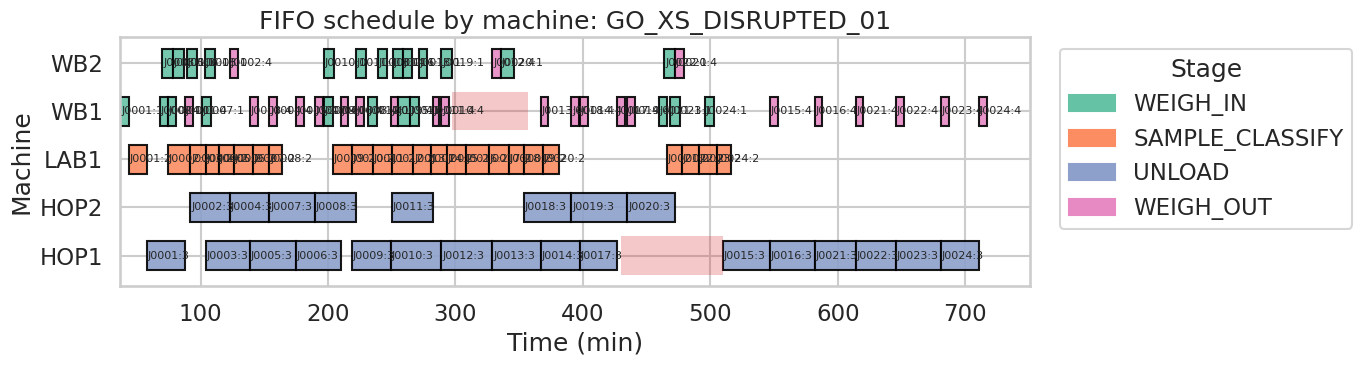

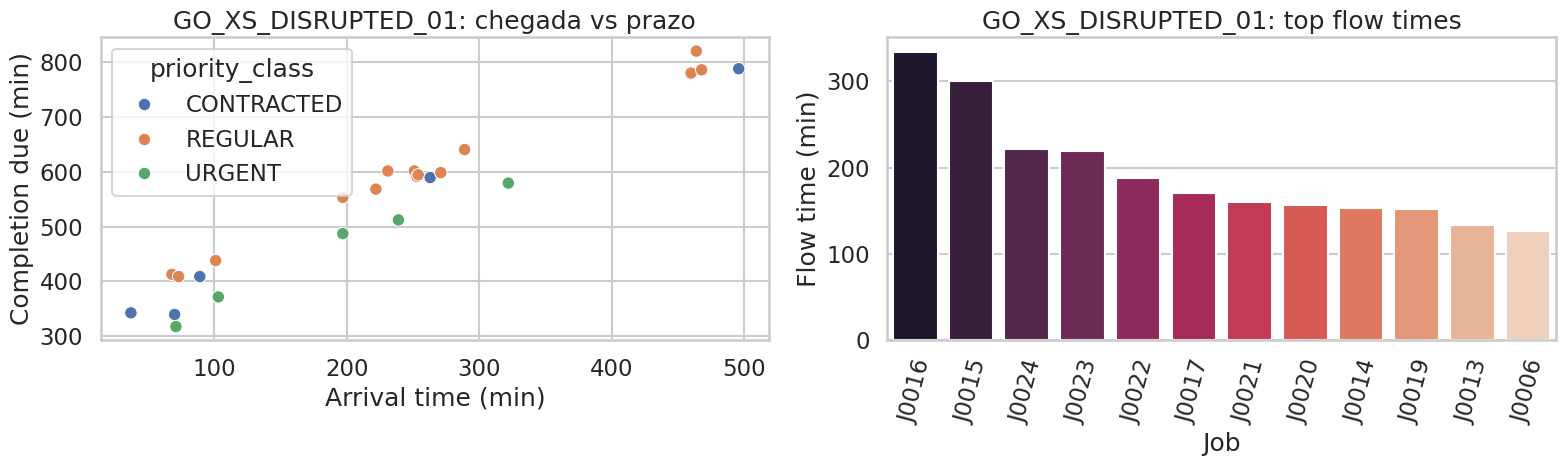

In [9]:
sample_instance = "GO_XS_DISRUPTED_01"

sample_params = params[params["instance_id"] == sample_instance]
sample_summary = catalog[catalog["instance_id"] == sample_instance]
sample_jobs = jobs_enriched[jobs_enriched["instance_id"] == sample_instance]
sample_metrics = job_metrics[job_metrics["instance_id"] == sample_instance]

display(sample_params)
display(sample_summary)
display(sample_jobs.head())
display(sample_metrics.describe().round(2))

fig = repl.schedule_plot(sample_instance, schedule, downtimes)
fig.savefig(ARTIFACT_DIR / f"{sample_instance.lower()}_fifo_schedule.png", dpi=160, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.scatterplot(data=sample_jobs, x="arrival_time_min", y="completion_due_min", hue="priority_class", ax=axes[0], s=80)
axes[0].set_title(f"{sample_instance}: chegada vs prazo")
axes[0].set_xlabel("Arrival time (min)")
axes[0].set_ylabel("Completion due (min)")

sns.barplot(data=sample_metrics.sort_values("flow_time_min", ascending=False).head(12), x="job_id", y="flow_time_min", hue="job_id", dodge=False, legend=False, ax=axes[1], palette="rocket")
axes[1].set_title(f"{sample_instance}: top flow times")
axes[1].set_xlabel("Job")
axes[1].set_ylabel("Flow time (min)")
axes[1].tick_params(axis="x", rotation=75)

fig.tight_layout()
fig.savefig(ARTIFACT_DIR / f"{sample_instance.lower()}_job_level_views.png", dpi=160, bbox_inches="tight")
plt.show()


## Results and notes

O notebook consolida uma leitura de qualidade do release oficial:

- o release está estruturalmente íntegro
- os audits reconciliam os valores centrais
- os regimes preservam a hierarquia operacional esperada
- a camada observacional reduz determinismo excessivo sem destruir semântica
- a base é forte o suficiente para servir como dataset pai de análises e futuras derivações com G2MILP


In [10]:
summary = {
    "dataset_version": manifest["dataset_version"],
    "instance_count": int(params["instance_id"].nunique()),
    "structural_pass_rate": float((structural_report["status"] == "PASS").mean()),
    "due_audit_match_share": float(audit_reconciliation["due_match_share"].mean()),
    "proc_audit_match_share": float(audit_reconciliation["proc_match_share"].mean()),
    "r2_due_slack_vs_priority": float(diagnostics["r2_due_slack_vs_priority"]),
    "r2_unload_proc_vs_load_machine_moisture": float(diagnostics["r2_unload_proc_vs_load_machine_moisture"]),
    "all_regime_order_checks_pass": bool(regime_checks["mean_flow_order_ok"].all() and regime_checks["p95_flow_order_ok"].all()),
    "g2milp_role": manifest["official_dataset_role"],
}
summary_df = pd.DataFrame([summary])
display(summary_df)

summary_lines = [
    "# Notebook Summary",
    "",
    f"- Dataset version: `{summary['dataset_version']}`",
    f"- Instances: `{summary['instance_count']}`",
    f"- Structural pass rate: `{summary['structural_pass_rate']:.4f}`",
    f"- Due audit match share: `{summary['due_audit_match_share']:.4f}`",
    f"- Proc audit match share: `{summary['proc_audit_match_share']:.4f}`",
    f"- R2 due slack vs priority: `{summary['r2_due_slack_vs_priority']:.4f}`",
    f"- R2 unload proc vs load+machine+moisture: `{summary['r2_unload_proc_vs_load_machine_moisture']:.4f}`",
    f"- Regime ordering checks all pass: `{summary['all_regime_order_checks_pass']}`",
    f"- Official role: `{summary['g2milp_role']}`",
]
summary_text = "\n".join(summary_lines)
(ARTIFACT_DIR / "notebook_summary.md").write_text(summary_text, encoding="utf-8")
summary_df.to_csv(ARTIFACT_DIR / "notebook_summary.csv", index=False)
display(Markdown(summary_text))


,dataset_version,instance_count,structural_pass_rate,due_audit_match_share,proc_audit_match_share,r2_due_slack_vs_priority,r2_unload_proc_vs_load_machine_moisture,all_regime_order_checks_pass,g2milp_role
0,1.1.0-observed,36,1.0,1.0,1.0,0.4848,0.4995,True,base_dataset_for_g2milp_instance_generation


# Notebook Summary

- Dataset version: `1.1.0-observed`
- Instances: `36`
- Structural pass rate: `1.0000`
- Due audit match share: `1.0000`
- Proc audit match share: `1.0000`
- R2 due slack vs priority: `0.4848`
- R2 unload proc vs load+machine+moisture: `0.4995`
- Regime ordering checks all pass: `True`
- Official role: `base_dataset_for_g2milp_instance_generation`

## Next steps

- usar este notebook como baseline de validação antes de gerar filhos com G2MILP
- ampliar com comparações entre esta release oficial e futuros datasets derivados
- adicionar testes de sensibilidade por família de máquina ou por política de geração
